In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
print("Libraries imported successfully")

Libraries imported successfully


In [7]:
df = pd.read_csv('../data/MachineLearningRating_v3.txt', sep='|')

In [8]:
df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [9]:
df.tail()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
1000093,31520,389,2015-04-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,Single,Male,South Africa,Western Cape,7493,Karoo 1 (Northeast of Cape Town),Northeast of CT,Mobility - Motor,4614100.0,Passenger Vehicle,2013,B.A.W,SASUKA 2.7i (16 SEAT),4.0,2693.0,110.0,B/S,4.0,2013/01/01 12:00:00 AM,NaN,Yes,No,0,More than 6 months,No,No,No,NaN,NaN,500000.0,Monthly,395.8481,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000094,31520,389,2015-06-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,Single,Male,South Africa,Western Cape,7493,Karoo 1 (Northeast of Cape Town),Northeast of CT,Mobility - Motor,4614100.0,Passenger Vehicle,2013,B.A.W,SASUKA 2.7i (16 SEAT),4.0,2693.0,110.0,B/S,4.0,2013/01/01 12:00:00 AM,NaN,Yes,No,0,More than 6 months,No,No,No,NaN,NaN,500000.0,Monthly,395.8481,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000095,31520,389,2015-08-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,Single,Male,South Africa,Western Cape,7493,Karoo 1 (Northeast of Cape Town),Northeast of CT,Mobility - Motor,4614100.0,Passenger Vehicle,2013,B.A.W,SASUKA 2.7i (16 SEAT),4.0,2693.0,110.0,B/S,4.0,2013/01/01 12:00:00 AM,NaN,Yes,No,0,More than 6 months,No,No,No,NaN,NaN,500000.0,Monthly,395.8481,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000096,31519,389,2014-07-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,Single,Male,South Africa,Western Cape,7493,Karoo 1 (Northeast of Cape Town),Northeast of CT,Mobility - Motor,4614100.0,Passenger Vehicle,2013,B.A.W,SASUKA 2.7i (16 SEAT),4.0,2693.0,110.0,B/S,4.0,2013/01/01 12:00:00 AM,NaN,Yes,No,0,More than 6 months,No,No,No,NaN,NaN,5000000.0,Monthly,2.6391,No excess,Passenger Liability,Passenger Liability,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,2.315000,0.0
1000097,31519,389,2015-02-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,Single,Male,South Africa,Western Cape,7493,Karoo 1 (Northeast of Cape Town),Northeast of CT,Mobility - Motor,4614100.0,Passenger Vehicle,2013,B.A.W,SASUKA 2.7i (16 SEAT),4.0,2693.0,110.0,B/S,4.0,2013/01/01 12:00:00 AM,NaN,Yes,No,0,More than 6 months,No,No,No,NaN,NaN,5000000.0,Monthly,2.6391,No excess,Passenger Liability,Passenger Liability,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,2.315000,0.0


In [10]:
df.iloc[100:150]

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
100,127444,10874,2015-01-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1513,Rand East,Rand East,Mobility - Motor,64092300.0,Passenger Vehicle,2004,VOLKSWAGEN,TOUAREG 5.0 V10 TDI TIP,10.0,4921.0,230.0,SUV,5.0,3/2004,161000.0,Yes,No,161000,More than 6 months,No,No,No,NaN,NaN,7500.0,Monthly,3.9679,No excess,Emergency Charges,Emergency Charges,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,3.480614,0.0
101,127444,10874,2015-04-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1513,Rand East,Rand East,Mobility - Motor,64092300.0,Passenger Vehicle,2004,VOLKSWAGEN,TOUAREG 5.0 V10 TDI TIP,10.0,4921.0,230.0,SUV,5.0,3/2004,161000.0,Yes,No,161000,More than 6 months,No,No,No,NaN,NaN,7500.0,Monthly,3.9679,No excess,Emergency Charges,Emergency Charges,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,3.480614,0.0
102,127444,10874,2015-06-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1513,Rand East,Rand East,Mobility - Motor,64092300.0,Passenger Vehicle,2004,VOLKSWAGEN,TOUAREG 5.0 V10 TDI TIP,10.0,4921.0,230.0,SUV,5.0,3/2004,161000.0,Yes,No,161000,More than 6 months,No,No,No,NaN,NaN,7500.0,Monthly,3.9679,No excess,Emergency Charges,Emergency Charges,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,3.480614,0.0
103,145246,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,3500.0,Monthly,1.1508,No excess,Signage and Vehicle Wraps,Signage and Vehicle Wraps,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,1.009474,0.0
104,145246,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,3500.0,Monthly,1.1508,No excess,Signage and Vehicle Wraps,Signage and Vehicle Wraps,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,1.009474,0.0
105,145246,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,3500.0,Monthly,1.1508,No excess,Signage and Vehicle Wraps,Signage and Vehicle Wraps,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
106,145254,12827,2015-01-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not

In [11]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000098, 52)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

In [13]:
df.dtypes

UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth             object
IsVATRegistered                bool
Citizenship                  object
LegalType                    object
Title                        object
Language                     object
Bank                         object
AccountType                  object
MaritalStatus                object
Gender                       object
Country                      object
Province                     object
PostalCode                    int64
MainCrestaZone               object
SubCrestaZone                object
ItemType                     object
mmcode                      float64
VehicleType                  object
RegistrationYear              int64
make                         object
Model                        object
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                     object
NumberOfDoors               

In [14]:
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])
df['TransactionMonth'].dtype

dtype('<M8[ns]')

In [15]:
df.describe()

,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1000098,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,2015-02-28 10:49:29.147423744,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
min,1.000000e+00,1.400000e+01,2013-10-01 00:00:00,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,2015-01-01 00:00:00,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2015-04-01 00:00:00,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,2015-06-01 00:00:00,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,2015-08-01 00:00:00,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05
std,6.329371e+04,5.290039e+03,NaN,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03


In [16]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Converted                   641901
Rebuilt                     641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
Cylinders                      552
cubiccapacity                  552
kilowatts                      552
NumberOfDoors                  552
VehicleIntroDate               552
Model                          552
make                           552
VehicleType                    552
mmcode                         552
bodytype                       552
CapitalOutstanding               2
dtype: int64

In [17]:
# Missing percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df.sort_values(by='Percentage', ascending=False).head(10)

,Missing Values,Percentage
NumberOfVehiclesInFleet,1000098.0,100.000000
CrossBorder,999400.0,99.930207
CustomValueEstimate,779642.0,77.956560
Converted,641901.0,64.183810
WrittenOff,641901.0,64.183810
Rebuilt,641901.0,64.183810
NewVehicle,153295.0,15.327998
Bank,145961.0,14.594670
AccountType,40232.0,4.022806
Gender,9536.0,0.953507


In [18]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [19]:
overall_loss_ratio = (
    df['TotalClaims'].sum() /
    df['TotalPremium'].sum()
)

print("Overall Loss Ratio:", round(overall_loss_ratio, 2))

Overall Loss Ratio: 1.05


In [20]:
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

df[['TotalPremium', 'TotalClaims', 'Margin']].iloc[700000:750000]

,TotalPremium,TotalClaims,Margin
700000,1.646842,0.0,1.646842
700001,2.854450,0.0,2.854450
700002,3.293596,0.0,3.293596
700003,3.293596,0.0,3.293596
700004,3.293596,0.0,3.293596
...,...,...,...
749995,0.400497,0.0,0.400497
749996,1.201491,0.0,1.201491
749997,1.201491,0.0,1.201491
749998,1.201491,0.0,1.201491


Although the majority of policies recorded zero claims, the portfolio exhibits a loss ratio above 1, indicating overall unprofitability. This suggests that a relatively small number of high-severity claims are disproportionately driving total losses, a common characteristic of insurance portfolios with heavily skewed claim distributions.

A loss ratio above 1 means:

ACIS paid out more in claims than it collected in premiums during the observed period.

Possible implications:

underpriced policies
insufficient risk segmentation
catastrophic claims exposure
inadequate premium adjustments

In [21]:
# Percentage of policies with claims
claim_percentage = (
    (df['TotalClaims'] > 0).mean()
) * 100

print(f"Percentage of policies with claims: {claim_percentage:.2f}%")

Percentage of policies with claims: 0.28%


In [22]:
df['TotalClaims'].describe()

count    1.000098e+06
mean     6.486119e+01
std      2.384075e+03
min     -1.200241e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.930921e+05
Name: TotalClaims, dtype: float64

In [23]:
# Group by Province
province_analysis = df.groupby('Province').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
})

# Create Loss Ratio
province_analysis['LossRatio'] = (
    province_analysis['TotalClaims'] /
    province_analysis['TotalPremium']
)

# Sort
province_analysis.sort_values(by='LossRatio', ascending=False)

,TotalPremium,TotalClaims,LossRatio
Province,,,
Gauteng,2.405377e+07,2.939415e+07,1.222018
KwaZulu-Natal,1.320908e+07,1.430138e+07,1.082693
Western Cape,9.806559e+06,1.038977e+07,1.059472
North West,7.490508e+06,5.920250e+06,0.790367
Mpumalanga,2.836292e+06,2.044675e+06,0.720897
Free State,5.213632e+05,3.549223e+05,0.680758
Limpopo,1.537324e+06,1.016477e+06,0.661199
Eastern Cape,2.140104e+06,1.356427e+06,0.633813
Northern Cape,3.165581e+05,8.949051e+04,0.282699


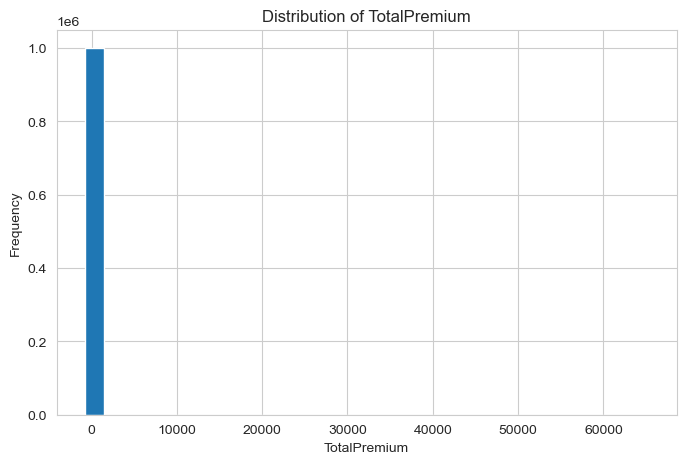

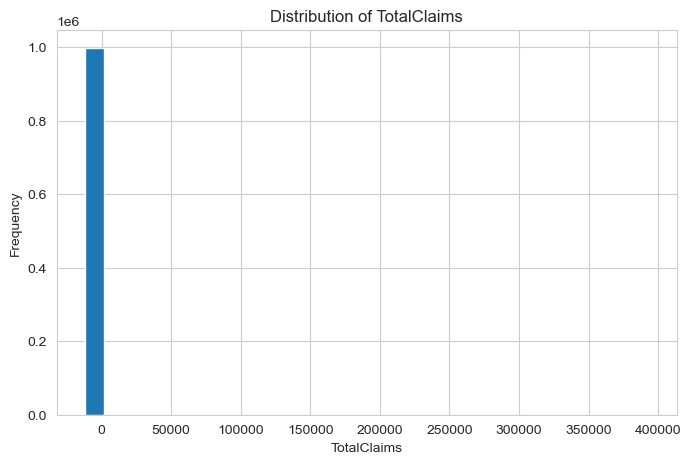

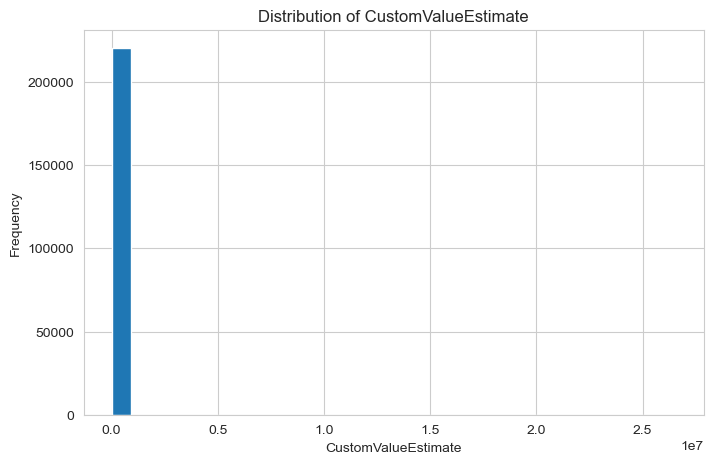

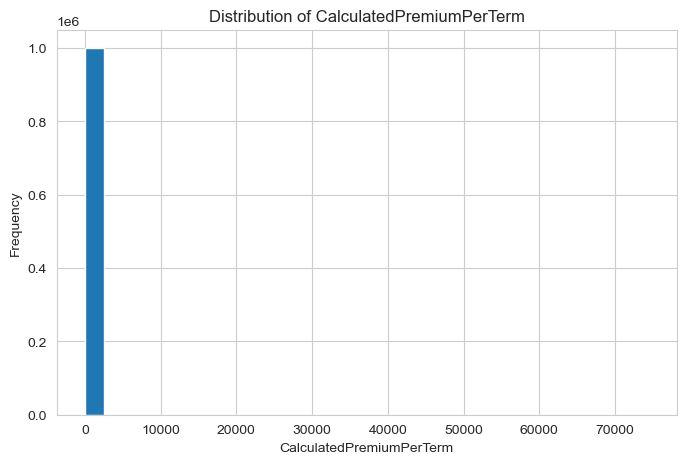

In [24]:
numerical_columns = [
    'TotalPremium',
    'TotalClaims',
    'CustomValueEstimate',
    'CalculatedPremiumPerTerm'
]

for col in numerical_columns:
    
    plt.figure(figsize=(8,5))
    
    plt.hist(df[col].dropna(), bins=30)
    
    plt.title(f'Distribution of {col}')
    
    plt.xlabel(col)
    
    plt.ylabel('Frequency')
    
    plt.show()

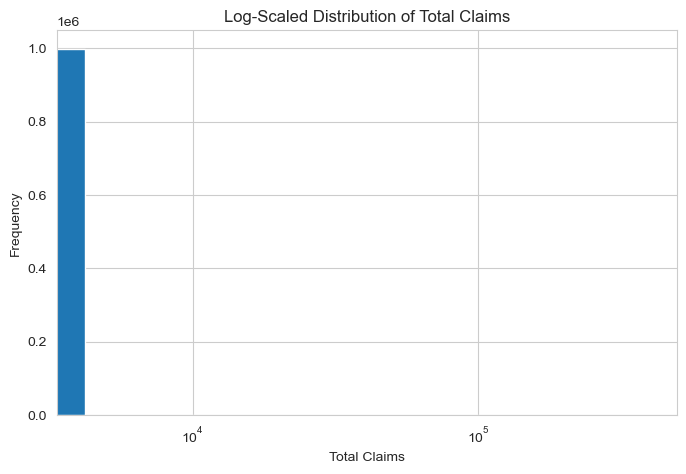

In [25]:
plt.figure(figsize=(8,5))

plt.hist(df['TotalClaims'] + 1, bins=50)

plt.xscale('log')

plt.title('Log-Scaled Distribution of Total Claims')

plt.xlabel('Total Claims')

plt.ylabel('Frequency')

plt.show()

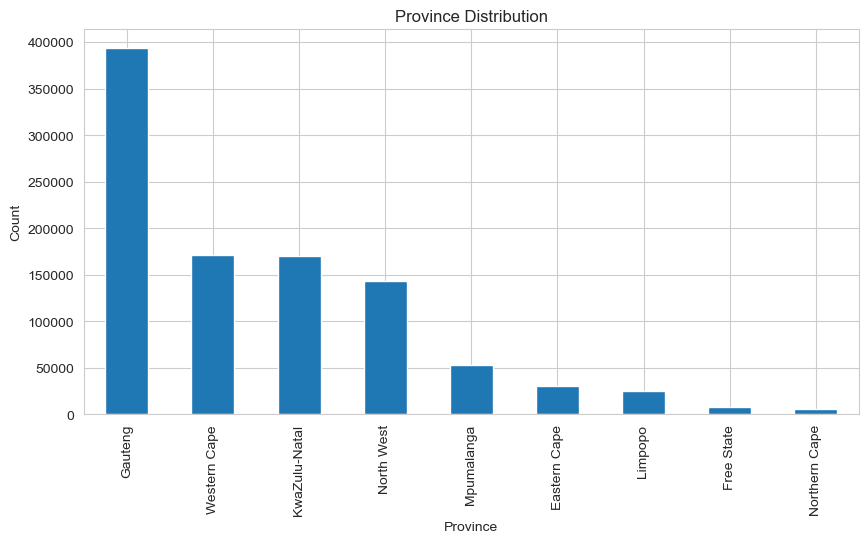

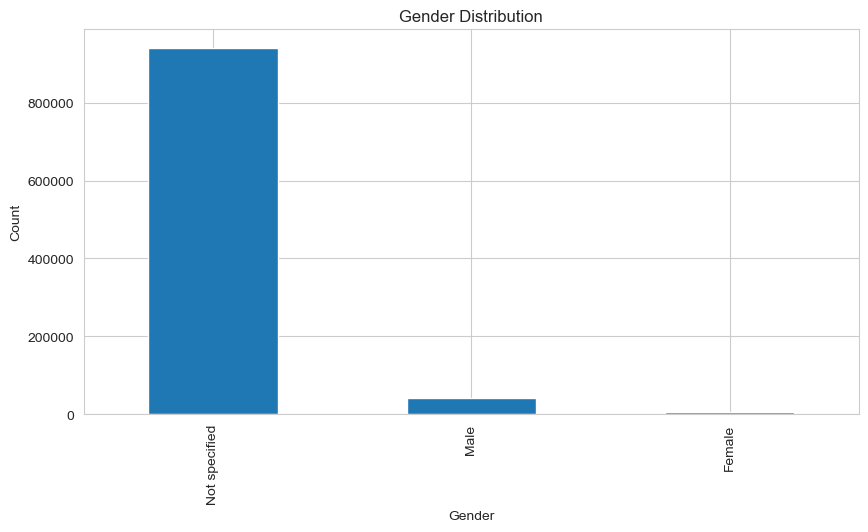

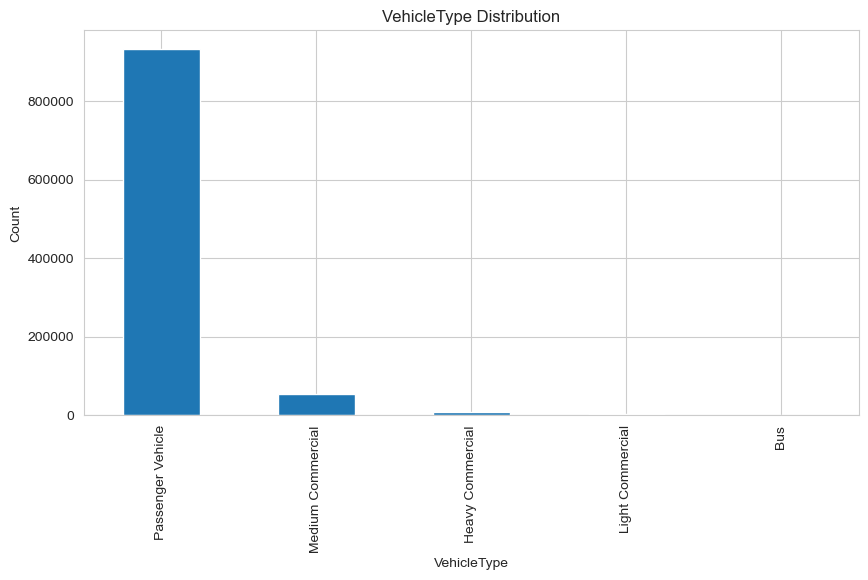

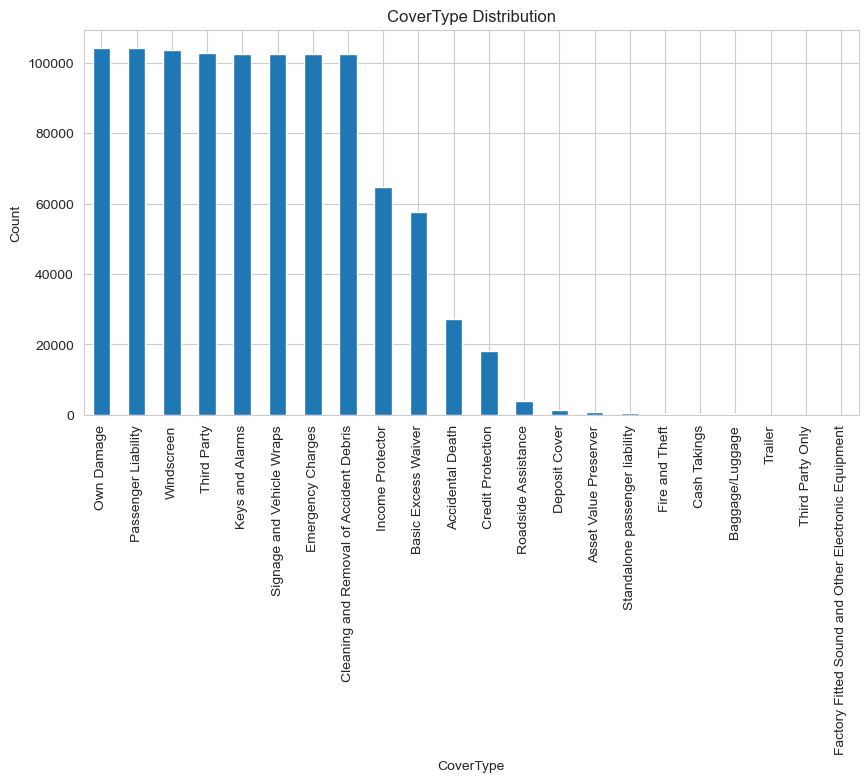

In [27]:
categorical_columns = [
    'Province',
    'Gender',
    'VehicleType',
    'CoverType'
]

for col in categorical_columns:
    
    plt.figure(figsize=(10,5))
    
    df[col].value_counts().plot(kind='bar')
    
    plt.title(f'{col} Distribution')
    
    plt.xlabel(col)
    
    plt.ylabel('Count')
    
    plt.show()

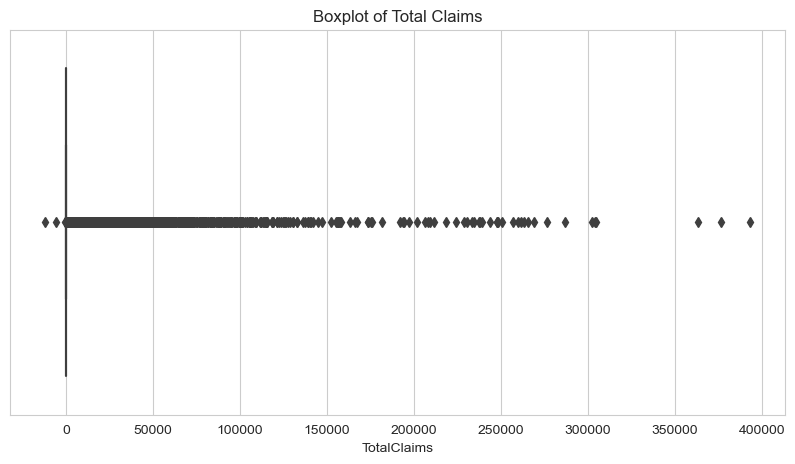

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['TotalClaims'])

plt.title('Boxplot of Total Claims')

plt.show()

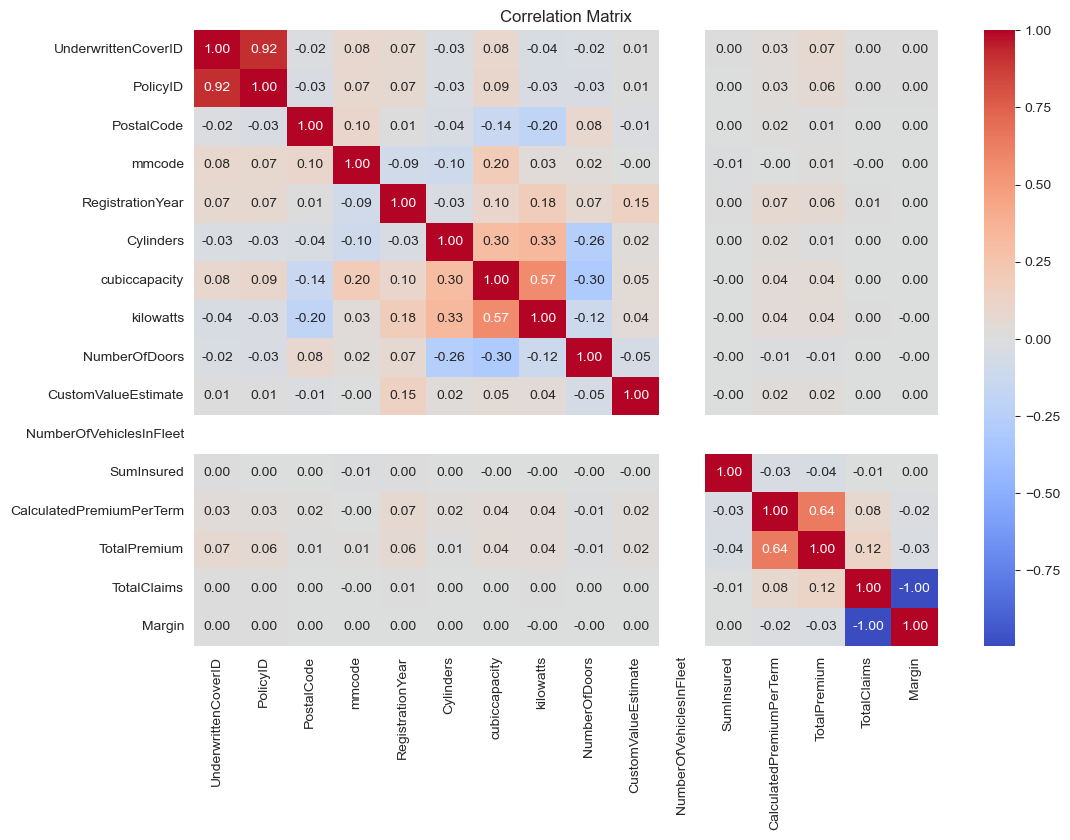

In [29]:
# Select numerical columns
numerical_df = df.select_dtypes(include=np.number)

# Correlation matrix
corr_matrix = numerical_df.corr()

# Plot
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')

plt.show()

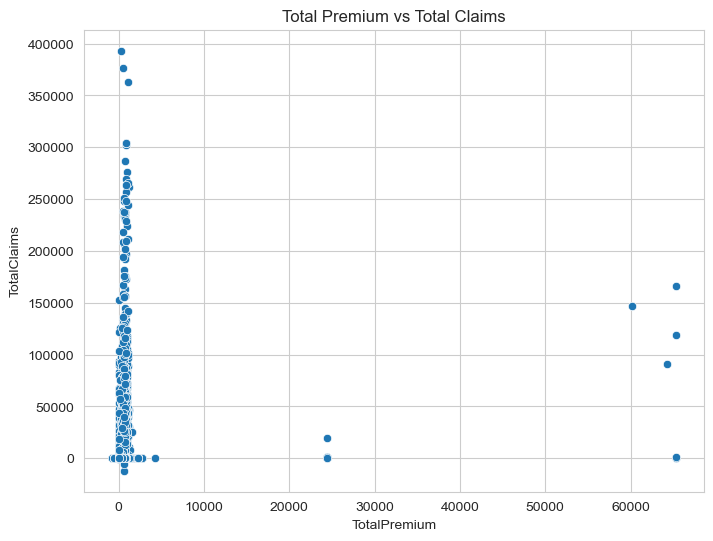

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='TotalPremium',
    y='TotalClaims'
)

plt.title('Total Premium vs Total Claims')

plt.show()

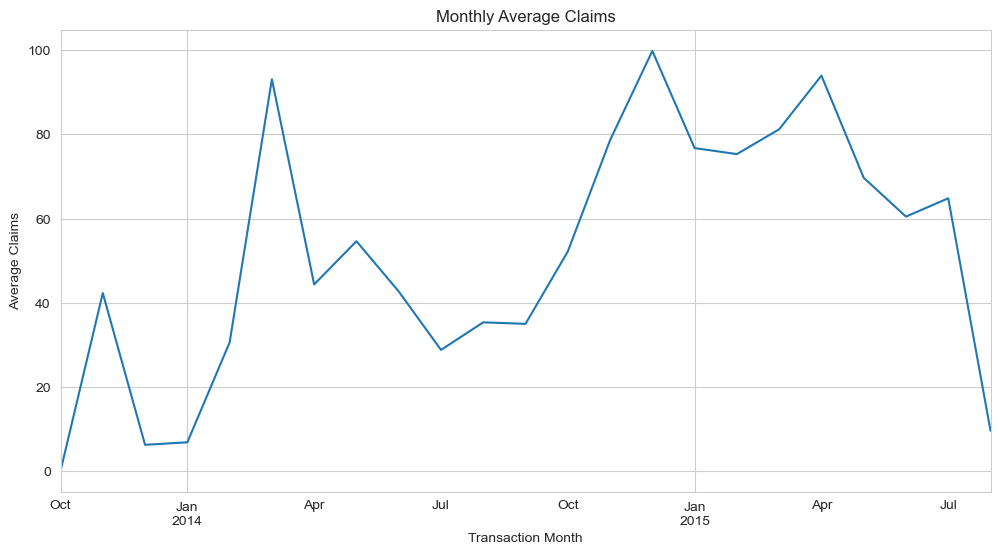

In [31]:
# Monthly claim severity
monthly_claims = (
    df.groupby('TransactionMonth')['TotalClaims']
    .mean()
)

plt.figure(figsize=(12,6))

monthly_claims.plot()

plt.title('Monthly Average Claims')

plt.xlabel('Transaction Month')

plt.ylabel('Average Claims')

plt.show()

In [32]:
# Claim occurrence flag
df['HasClaim'] = np.where(df['TotalClaims'] > 0, 1, 0)

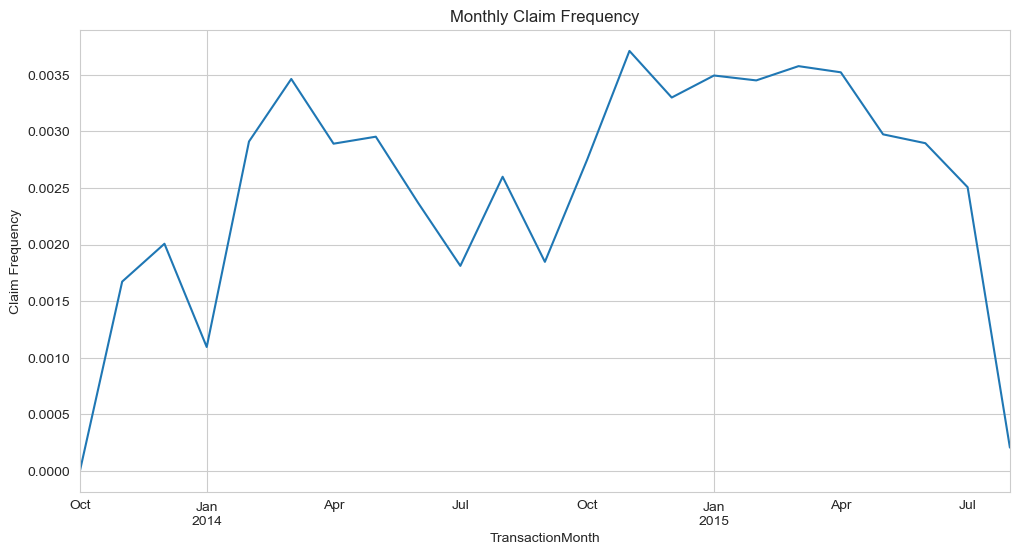

In [34]:
claim_frequency = (
    df.groupby('TransactionMonth')['HasClaim']
    .mean()
)

plt.figure(figsize=(12,6))

claim_frequency.plot()

plt.title('Monthly Claim Frequency')

plt.ylabel('Claim Frequency')

plt.show()

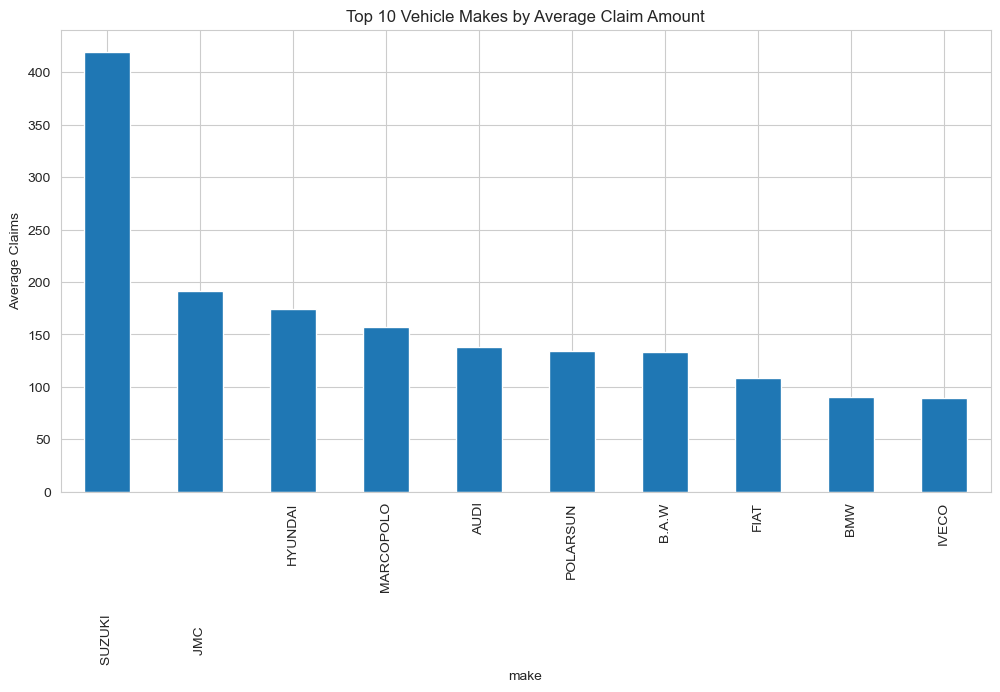

In [36]:
vehicle_claims = (
    df.groupby('make')['TotalClaims']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

vehicle_claims.plot(kind='bar')

plt.title('Top 10 Vehicle Makes by Average Claim Amount')

plt.ylabel('Average Claims')

plt.show()

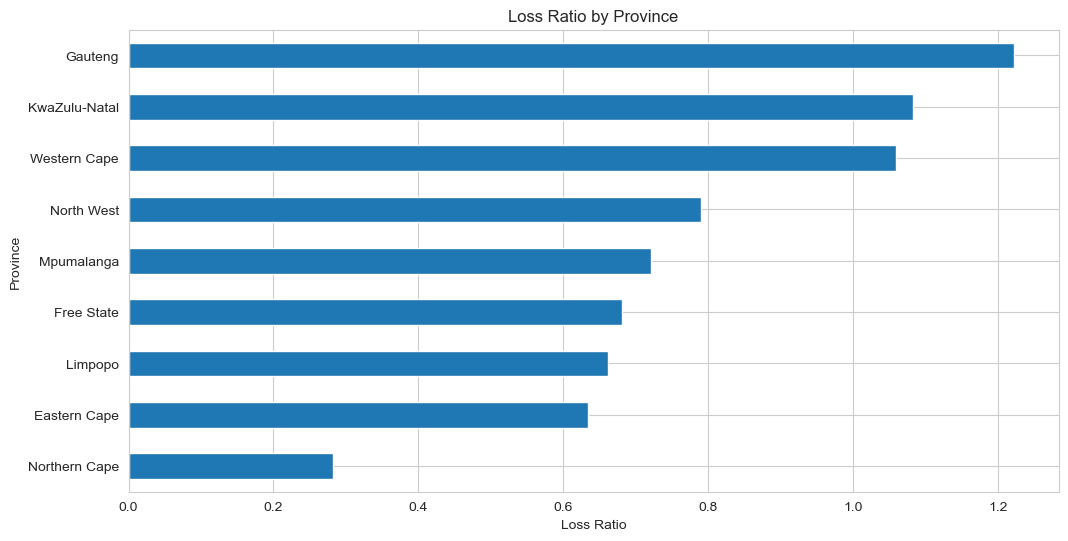

In [37]:
province_loss_ratio = province_analysis['LossRatio'].sort_values()

plt.figure(figsize=(12,6))

province_loss_ratio.plot(kind='barh')

plt.title('Loss Ratio by Province')

plt.xlabel('Loss Ratio')

plt.show()

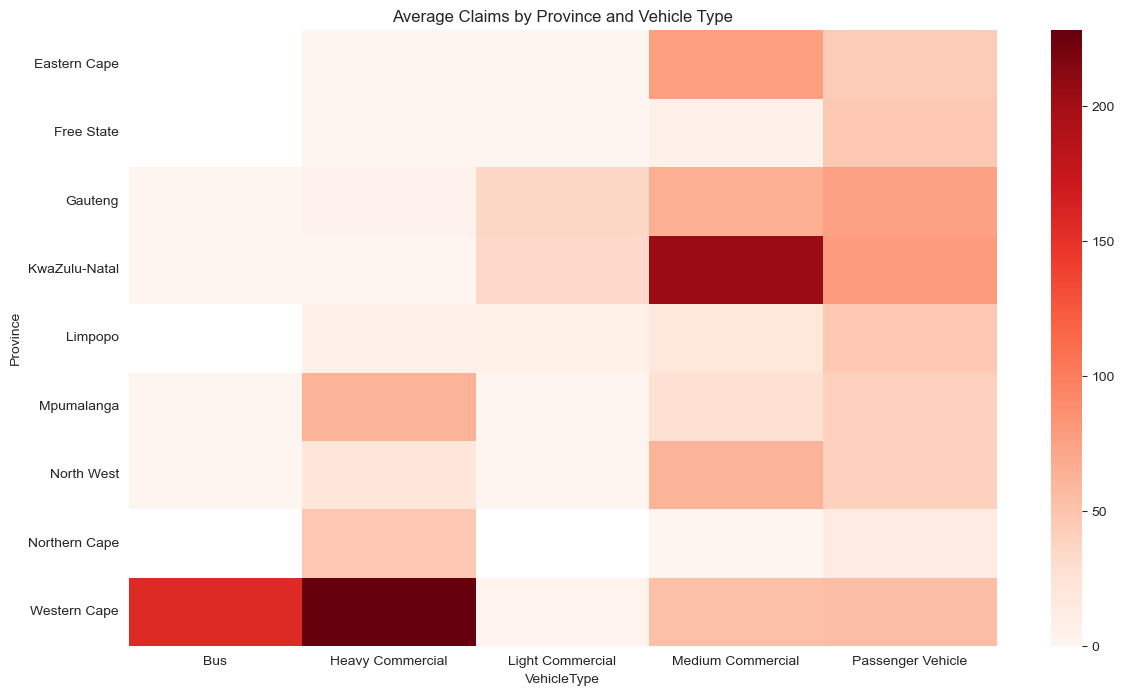

In [38]:
pivot_table = pd.pivot_table(
    df,
    values='TotalClaims',
    index='Province',
    columns='VehicleType',
    aggfunc='mean'
)

plt.figure(figsize=(14,8))

sns.heatmap(pivot_table,
            cmap='Reds')

plt.title('Average Claims by Province and Vehicle Type')

plt.show()

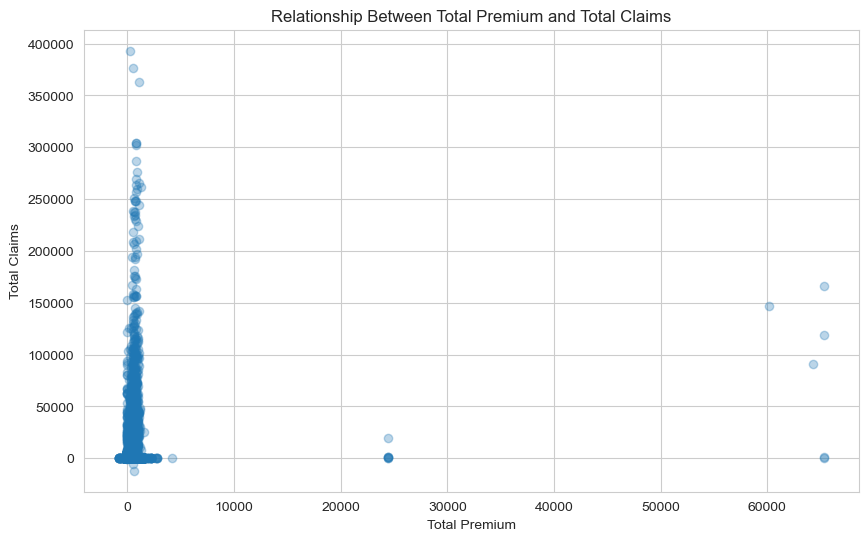

In [40]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['TotalPremium'],
    df['TotalClaims'],
    alpha=0.3
)

plt.title('Relationship Between Total Premium and Total Claims')

plt.xlabel('Total Premium')

plt.ylabel('Total Claims')

plt.show()